Número de muestras: 12606


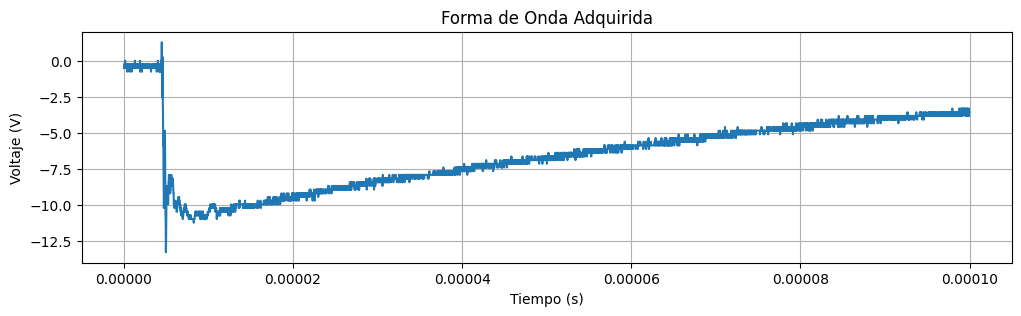

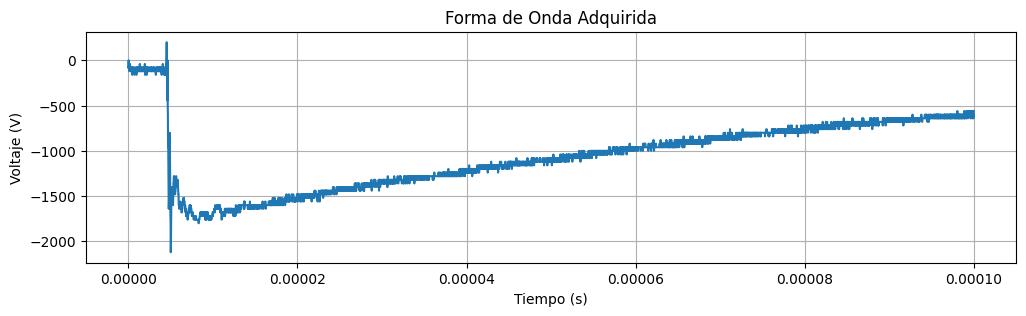

In [31]:
import time
from struct import unpack
import sys
import pyvisa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py

def read_bin():
    headerlen = 60
    #vdiv = get_channel_scale(1)
    data = np.fromfile("0001-Red-H1.bin", dtype=np.int8)
    num_muestras = int(len(data[headerlen + 8:]) / 2)
    print("Número de muestras:", num_muestras)
    waveform_raw = unpack(f'<{num_muestras}h', data[headerlen + 8:])
    waveform_raw = waveform_raw[:5000]
    #waveform_raw = unpack('<%dh' % (int(len(data[headerlen + 8:]) / 2)), data[headerlen + 8:])
    num = len(waveform_raw)
    waveform = [0] * num
    for i in range(num):
        waveform[i] = waveform_raw[i] / 1000
    return waveform

def read_csv():
    df = pd.read_csv("0001-Red-H1.csv")
    return df.values.flatten()

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (V)")
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    dt = 20e-9

    wave1 = read_bin()
    plot_waveform(wave1, dt)
    wave2 = read_csv()
    plot_waveform(wave2, dt)